In [2]:

import pandas as pd

url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

In [3]:
df=pd.read_csv(url)

In [4]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [6]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [7]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [14]:
target="tip"
print("\n target variable: ",target)


 target variable:  tip


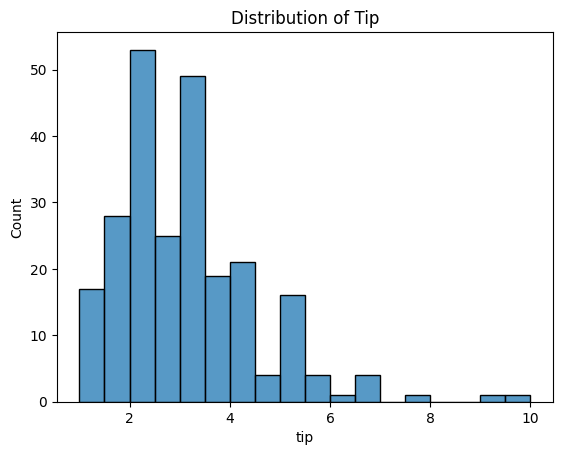

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.histplot(df['tip'],)
plt.title(f"Distribution of Tip")
plt.show()
  


    
  


    

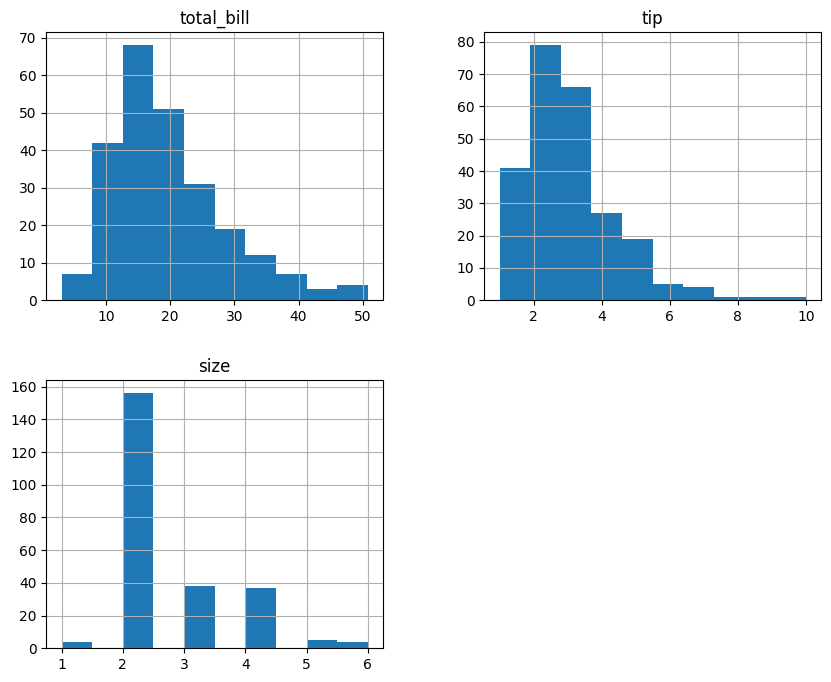

In [23]:
df.hist(figsize=(10,8))
plt.show()

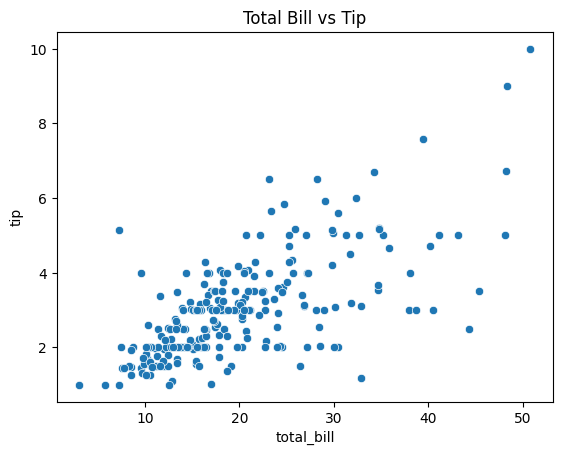

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('tips')

plt.figure()
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title("Total Bill vs Tip")
plt.show()

print(df[['total_bill','tip','size']].corr())

In [21]:
print(df.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


<Axes: >

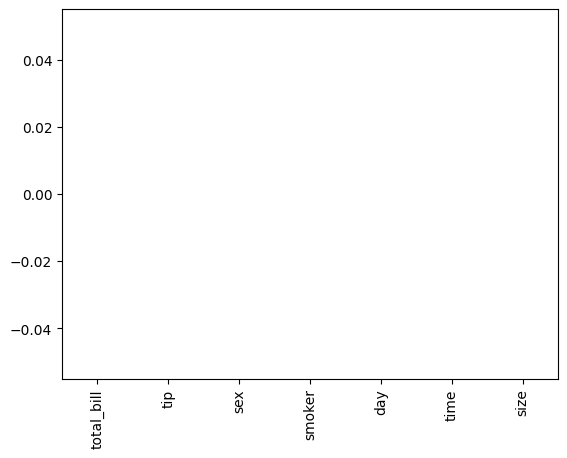

In [19]:
df.isnull().sum().plot(kind='bar')

In [ ]:
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: -2.8224999999999945
Upper Bound: 40.29749999999999


In [ ]:
df_clean = df[(df['total_bill'] >= lower) & (df['total_bill'] <= upper)]

print( df.shape)
print( df_clean.shape)

(244, 7)
(235, 7)


In [ ]:
print( df['total_bill'].describe())
print( df_clean['total_bill'].describe())

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64
count    235.000000
mean      18.798681
std        7.438468
min        3.070000
25%       13.215000
50%       17.460000
75%       23.135000
max       40.170000
Name: total_bill, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_clean['total_bill_scaled'] = scaler.fit_transform(df_clean[['total_bill']])

print( df_clean['total_bill'].describe())
print( df_clean['total_bill_scaled'].describe())

count    235.000000
mean      18.798681
std        7.438468
min        3.070000
25%       13.215000
50%       17.460000
75%       23.135000
max       40.170000
Name: total_bill, dtype: float64
count    2.350000e+02
mean    -2.910202e-16
std      1.002134e+00
min     -2.119019e+00
25%     -7.522515e-01
50%     -1.803514e-01
75%      5.842029e-01
max      2.879213e+00
Name: total_bill_scaled, dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X = df_clean[['total_bill']]
y = df_clean['tip']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


Intercept: 0.9292974084316608
Slope: 0.10491118865709444


In [11]:
print("R2 Score:", r2_score(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))

NameError: name 'r2_score' is not defined

In [ ]:
cov = np.cov(df_clean['total_bill'], df_clean['tip'])[0][1]
var = np.var(df_clean['total_bill'])

manual_slope = cov / var

print("Manual Slope:", manual_slope)
print("Library Slope:", model.coef_[0])

Manual Slope: 0.10535952707015896
Library Slope: 0.10491118865709444
